Random Forest Implementation

In [17]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, average_precision_score, log_loss, 
    classification_report, RocCurveDisplay
)
from CartClassifier import CARTClassifier
from metrics import evaluate_model

# 1. Load data
df = pd.read_csv("../data/features/processed_data_with_position_specific_features.csv")

# 2. Preprocess (Drop non-feature strings)
DROP_COLS = ["peptide", "hla_sequence", "index", "HLA"]
TARGET_COL = "Label"
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# 3. Handle categorical columns (Encoding)
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]
df = pd.get_dummies(df, columns=cat_cols)

# 4. Define Features (X) and Target (y)
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL])

# 5. Load pre-defined split indices
train_idx = np.load("../data/splits/train_idx.npy")
val_idx   = np.load("../data/splits/val_idx.npy")
test_idx  = np.load("../data/splits/test_idx.npy")

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_val, y_val     = X.iloc[val_idx], y[val_idx]
X_test, y_test   = X.iloc[test_idx], y[test_idx]


In [18]:
#Random Forest Implementation

class RandomForestFromScratch:
    def __init__(self, n_estimators=50, max_depth=10, min_samples_split=2, 
                 min_samples_leaf=1, max_features=None):
        self.n_estimators      = n_estimators
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.max_features      = max_features
        self.trees             = []

    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X.iloc[indices].values, y[indices]

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            X_sample, y_sample = self._bootstrap_sample(X, y)
            tree = CARTClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features   # ← now passed through
            )
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict_proba(self, X):
        X_vals = X.values if isinstance(X, pd.DataFrame) else X
        all_tree_preds = np.array([tree.predict_proba(X_vals)[:, 1] for tree in self.trees])  # ← soft probs
        prob_pos = np.mean(all_tree_preds, axis=0)
        return np.vstack([1 - prob_pos, prob_pos]).T

    def predict(self, X):
        probas = self.predict_proba(X)
        return np.argmax(probas, axis=1)

def run_performance_assessment(model, X, y, set_name="Test", show_report=False):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-Score": f1_score(y, y_pred),
        "Log-Loss": log_loss(y, y_prob),
        "ROC-AUC": roc_auc_score(y, y_prob),
        "AUPRC": average_precision_score(y, y_prob)
    }
    
    print(f"-- {set_name} --")
    for name, value in metrics.items():
        print(f"{name:10}: {value:.4f}")
    
    if show_report:
        print("\nClassification Report:\n", classification_report(y, y_pred))
        RocCurveDisplay.from_predictions(y, y_prob)
        plt.title(f"ROC Curve: {set_name}")
        plt.show()
    
    print("-" * 30 + "\n")
    return metrics

# Save function 
def save_model(model, features, params, version, notes=""):
    joblib.dump({
        "model": model,
        "features": features,
        "params": params,
        "model_name": "RandomForestFromScratch",
        "version": version,
        "notes": notes
    }, f"../models/rf_{version}.pkl")
    print(f"Model {version} saved successfully!")

Hyperparameter Tuning

In [19]:
# DT HYPERPARAMETER TUNING 
depth_options = [5, 10, 15]
split_options = [2, 5, 10]
leaf_options  = [1, 2, 5]

best_auc    = 0
best_params = {}
results     = []

for depth in depth_options:
    for split in split_options:
        for leaf in leaf_options:
            temp_model = CARTClassifier(max_depth=depth, min_samples_split=split, min_samples_leaf=leaf)
            temp_model.fit(X_train.values, y_train)
            val_preds   = temp_model.predict_proba(X_val.values)[:, 1]
            current_auc = roc_auc_score(y_val, val_preds)
            results.append({'params': {'max_depth': depth, 'min_samples_split': split, 'min_samples_leaf': leaf}, 'auc': current_auc})
            if current_auc > best_auc:
                best_auc    = current_auc
                best_params = {'max_depth': depth, 'min_samples_split': split, 'min_samples_leaf': leaf}

joblib.dump(results, "../models/grid_search_results.pkl")
print(f"Best DT Validation AUC: {best_auc:.4f}")
print(f"Best DT Parameters:     {best_params}")


Best DT Validation AUC: 0.8190
Best DT Parameters:     {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5}


In [20]:

# RF HYPERPARAMETER TUNING 
n_features           = X_train.shape[1]
default_max_features = int(np.sqrt(n_features))

n_estimators_options = [50, 100]
depth_options_rf     = [5, 10] 
leaf_options_rf      = [1, 2]
 
#n_estimators_options = [50, 100, 200]
#depth_options_rf     = [5, 10, 15]
#leaf_options_rf      = [1, 2, 5]

best_rf_auc    = 0
best_rf_params = {}
rf_results     = []

for n_est in n_estimators_options:
    for depth in depth_options_rf:
        for leaf in leaf_options_rf:
            rf_temp = RandomForestFromScratch(
                n_estimators=n_est, max_depth=depth,
                min_samples_split=2, min_samples_leaf=leaf,
                max_features=default_max_features
            )
            rf_temp.fit(X_train, y_train)
            val_preds = rf_temp.predict_proba(X_val)[:, 1]
            auc       = roc_auc_score(y_val, val_preds)
            rf_results.append({'params': {'n_estimators': n_est, 'max_depth': depth, 'min_samples_leaf': leaf}, 'auc': auc})
            if auc > best_rf_auc:
                best_rf_auc    = auc
                best_rf_params = {'n_estimators': n_est, 'max_depth': depth,
                                  'min_samples_split': 2, 'min_samples_leaf': leaf,
                                  'max_features': default_max_features}

joblib.dump(rf_results, "../models/rf_grid_search_results.pkl")
print(f"Best RF Validation AUC: {best_rf_auc:.4f}")
print(f"Best RF Parameters:     {best_rf_params}")

# BUILD FINAL MODELS 
dt_model = CARTClassifier(**best_params)
dt_model.fit(X_train.values, y_train)

rf_model = RandomForestFromScratch(**best_rf_params)
rf_model.fit(X_train, y_train)

Best RF Validation AUC: 0.8668
Best RF Parameters:     {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 17}


-- Training Set --
Accuracy  : 0.8588
Precision : 0.8099
Recall    : 0.8959
F1-Score  : 0.8507
Log-Loss  : 0.3290
ROC-AUC   : 0.9527
AUPRC     : 0.9500
------------------------------

-- Validation Set --
Accuracy  : 0.7752
Precision : 0.7272
Recall    : 0.8219
F1-Score  : 0.7716
Log-Loss  : 0.4582
ROC-AUC   : 0.8641
AUPRC     : 0.8332
------------------------------


Model    : Random Forest (Test Set)
Accuracy : 0.7917
ROC-AUC  : 0.8766
MCC      : 0.5917

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.74      0.80       991
           1       0.73      0.85      0.79       824

    accuracy                           0.79      1815
   macro avg       0.80      0.80      0.79      1815
weighted avg       0.80      0.79      0.79      1815



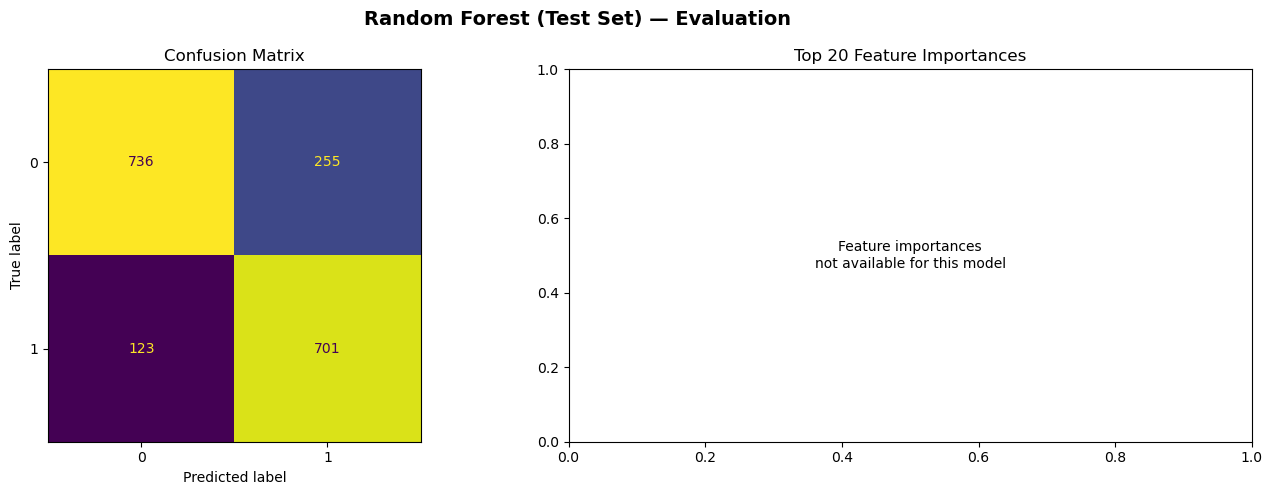

Plot saved to random_forest_(test_set)_metrics.png


{'model': 'Random Forest (Test Set)',
 'accuracy': 0.7917355371900826,
 'roc_auc': np.float64(0.8765773025187857),
 'mcc': np.float64(0.5917407234178861)}

In [21]:

# 6. Final Performance Assessment (Train, Validation, and Test)

train_results = run_performance_assessment(rf_model, X_train, y_train, "Training Set")
val_results   = run_performance_assessment(rf_model, X_val, y_val, "Validation Set")

evaluate_model(rf_model, X_test, y_test, X, model_name="Random Forest (Test Set)")


In [22]:
save_model(
    model=rf_model, 
    features=X.columns.tolist(), 
    params=best_params, 
    version="v1", 
    notes="Position specific features, tuned on validation set"
)

Model v1 saved successfully!


In [23]:
def evaluate_independent_set(file_path, display_name):
    df_ind = pd.read_csv(file_path)
    
    # Preprocess
    TARGET_COL = "Label"
    X_ind = df_ind.drop(columns=[TARGET_COL] if TARGET_COL in df_ind.columns else [])
    X_ind = pd.get_dummies(X_ind)
    X_ind = X_ind.reindex(columns=X.columns, fill_value=0)
    y_ind = df_ind[TARGET_COL].values
    
    return evaluate_model(
        model=rf_model, 
        X_test=X_ind, 
        y_test=y_ind, 
        X=X, 
        model_name=f"Random Forest ({display_name})"
    )

/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



Model    : Random Forest (Dengue)
Accuracy : 1.0000
ROC-AUC  : nan
MCC      : 0.0000

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       408

    accuracy                           1.00       408
   macro avg       1.00      1.00      1.00       408
weighted avg       1.00      1.00      1.00       408



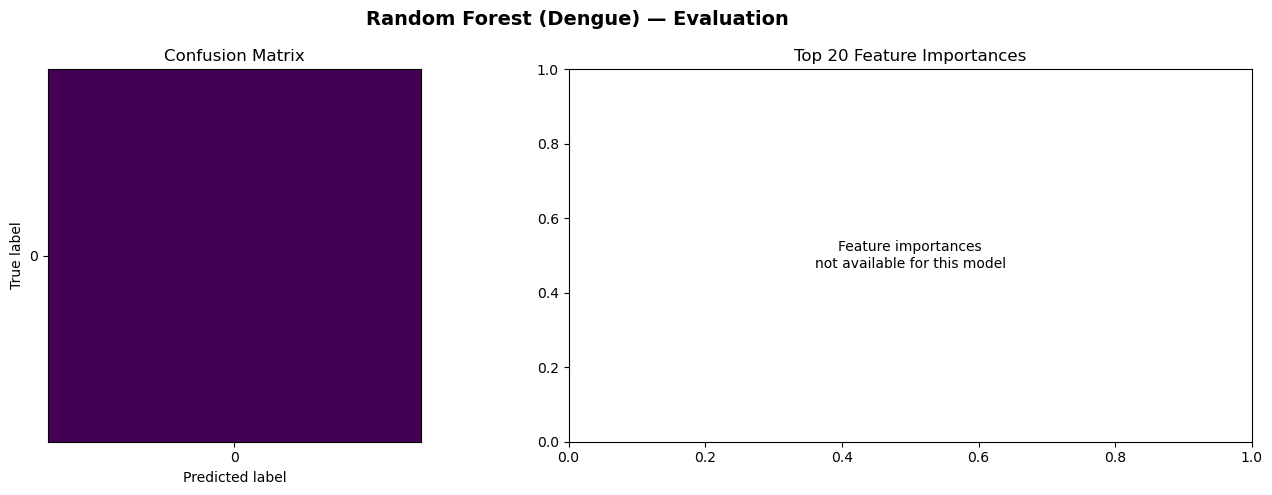

Plot saved to random_forest_(dengue)_metrics.png

Model    : Random Forest (SARS-CoV-2)
Accuracy : 0.3804
ROC-AUC  : 0.6185
MCC      : 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           1       0.38      1.00      0.55        35

    accuracy                           0.38        92
   macro avg       0.19      0.50      0.28        92
weighted avg       0.14      0.38      0.21        92



/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


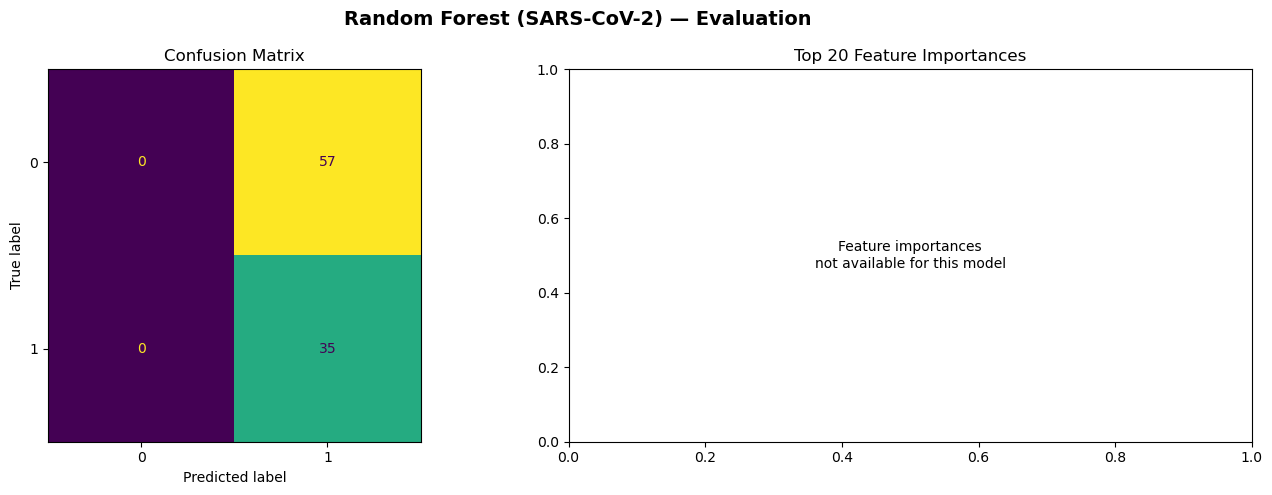

Plot saved to random_forest_(sars-cov-2)_metrics.png

Model    : Random Forest (Neoantigen)
Accuracy : 0.3985
ROC-AUC  : 0.6257
MCC      : 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       314
           1       0.40      1.00      0.57       208

    accuracy                           0.40       522
   macro avg       0.20      0.50      0.28       522
weighted avg       0.16      0.40      0.23       522



/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


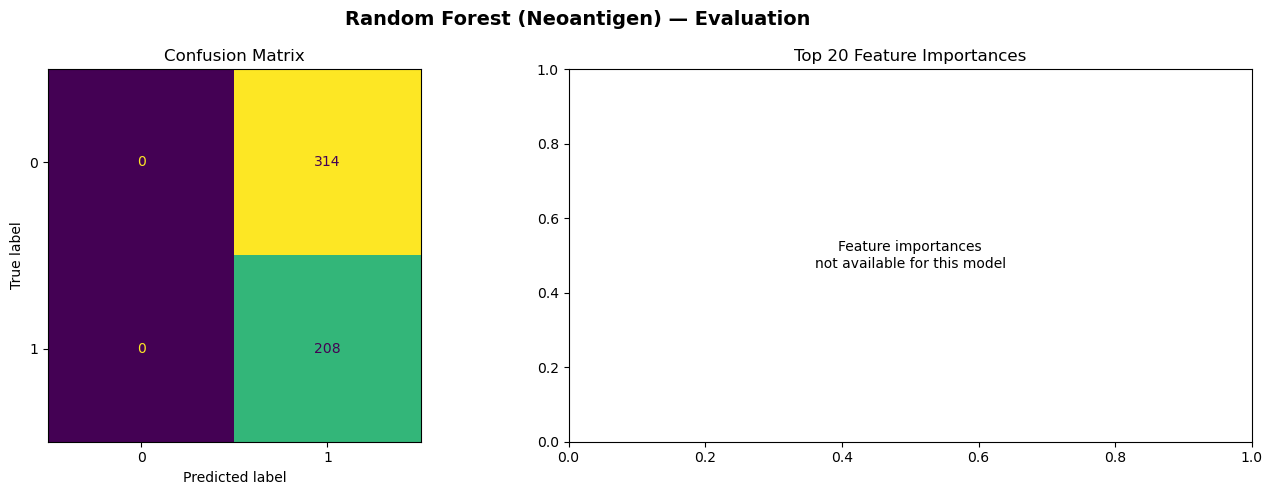

Plot saved to random_forest_(neoantigen)_metrics.png


In [24]:
# 8. Independent External Evaluations
external_data_map = {
    "../data/independent_tests/processed_dengue_test_with_position_specific_features.csv": "Dengue",
    "../data/independent_tests/processed_sars_cov_2_with_position_specific_features.csv": "SARS-CoV-2",
    "../data/independent_tests/processed_neoantigen_test_with_position_specific_features.csv": "Neoantigen"
}


for path, name in external_data_map.items():
    evaluate_independent_set(path, name)

Model Comparison: Plotting DT and Random Forest Models

In [11]:
import os
os.makedirs("../figures", exist_ok=True)

/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that cas

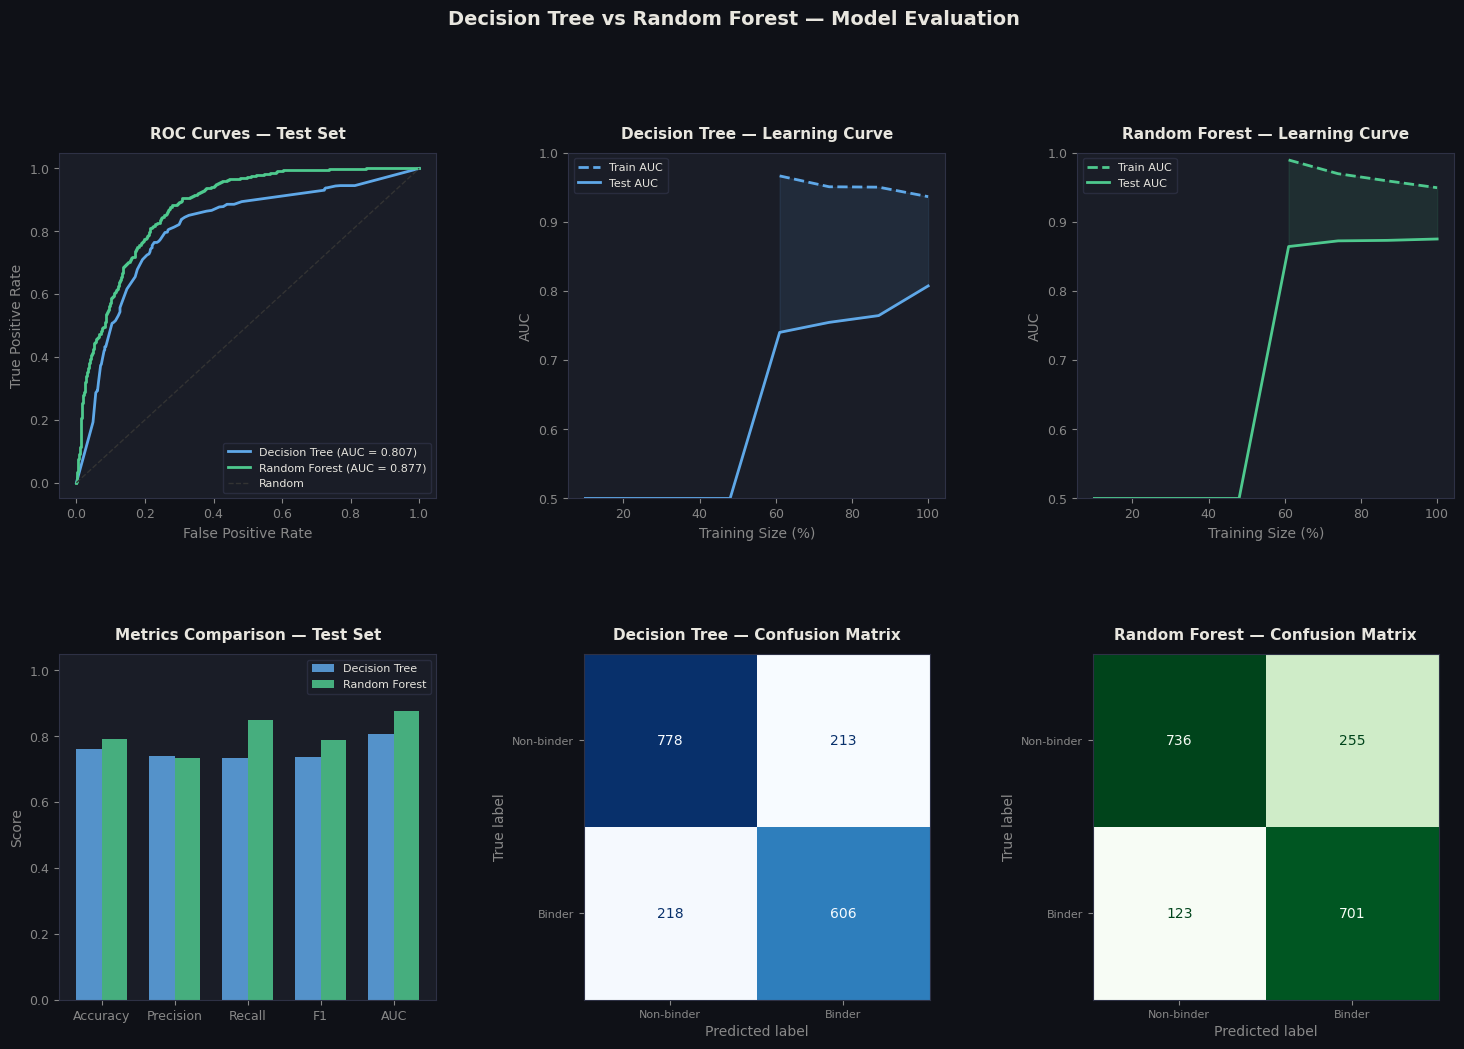

Plot saved to ../figures/combined_model_evaluation.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, 
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.model_selection import learning_curve

# 1. Get predictions from both models
# DT - refit final_cart on the same split
dt_final = CARTClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1)
dt_final.fit(X_train.values, y_train)

# RF - already trained as rf_model
# Get probabilities on test set
dt_prob  = dt_final.predict_proba(X_test.values)[:, 1]
rf_prob  = rf_model.predict_proba(X_test)[:, 1]
dt_pred  = dt_final.predict(X_test.values)
rf_pred  = rf_model.predict(X_test)

#  2. ROC CURVES
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

#  3. LEARNING CURVES (AUC vs training size)
train_sizes = np.linspace(0.1, 1.0, 8)
dt_train_aucs, dt_val_aucs = [], []
rf_train_aucs, rf_val_aucs = [], []

X_train_vals = X_train.values

for frac in train_sizes:
    n = int(len(X_train_vals) * frac)
    X_sub, y_sub = X_train_vals[:n], y_train[:n]

    # DT
    tmp_dt = CARTClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1)
    tmp_dt.fit(X_sub, y_sub)
    dt_train_aucs.append(roc_auc_score(y_sub, tmp_dt.predict_proba(X_sub)[:, 1]))
    dt_val_aucs.append(roc_auc_score(y_test, tmp_dt.predict_proba(X_test.values)[:, 1]))

    # RF
    tmp_rf = RandomForestFromScratch(
        n_estimators=50,
        max_depth=best_rf_params['max_depth'],
        min_samples_split=2,
        min_samples_leaf=best_rf_params['min_samples_leaf'],
        max_features=best_rf_params['max_features']
    )
    tmp_rf.fit(X_train.iloc[:n], y_sub)
    rf_train_aucs.append(roc_auc_score(y_sub, tmp_rf.predict_proba(X_train.iloc[:n])[:, 1]))
    rf_val_aucs.append(roc_auc_score(y_test, tmp_rf.predict_proba(X_test)[:, 1]))

# 4. CONFUSION MATRICES 
dt_cm = confusion_matrix(y_test, dt_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

# 5. PLOT EVERYTHING 
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

DARK   = '#0f1117'
CARD   = '#1a1d27'
DT_COL = '#5fa8e8'
RF_COL = '#4ec98e'
TEXT   = '#e8e6df'
MUTED  = '#888888'

def style_ax(ax, title):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2e3145')

# Panel 1: ROC Curves 
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(dt_fpr, dt_tpr, color=DT_COL, lw=2, label=f'Decision Tree (AUC = {dt_auc:.3f})')
ax1.plot(rf_fpr, rf_tpr, color=RF_COL, lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
ax1.plot([0,1],[0,1], color='#333', lw=1, linestyle='--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=8, facecolor=CARD, labelcolor=TEXT, edgecolor='#2e3145')
style_ax(ax1, 'ROC Curves — Test Set')

# Panel 2: DT Learning Curve
ax2 = fig.add_subplot(gs[0, 1])
sizes_pct = [int(s * 100) for s in train_sizes]
ax2.plot(sizes_pct, dt_train_aucs, color=DT_COL, lw=2, linestyle='--', label='Train AUC')
ax2.plot(sizes_pct, dt_val_aucs,   color=DT_COL, lw=2, label='Test AUC')
ax2.fill_between(sizes_pct, dt_train_aucs, dt_val_aucs, alpha=0.1, color=DT_COL)
ax2.set_xlabel('Training Size (%)')
ax2.set_ylabel('AUC')
ax2.set_ylim(0.5, 1.0)
ax2.legend(fontsize=8, facecolor=CARD, labelcolor=TEXT, edgecolor='#2e3145')
style_ax(ax2, 'Decision Tree — Learning Curve')

# Panel 3: RF Learning Curve 
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(sizes_pct, rf_train_aucs, color=RF_COL, lw=2, linestyle='--', label='Train AUC')
ax3.plot(sizes_pct, rf_val_aucs,   color=RF_COL, lw=2, label='Test AUC')
ax3.fill_between(sizes_pct, rf_train_aucs, rf_val_aucs, alpha=0.1, color=RF_COL)
ax3.set_xlabel('Training Size (%)')
ax3.set_ylabel('AUC')
ax3.set_ylim(0.5, 1.0)
ax3.legend(fontsize=8, facecolor=CARD, labelcolor=TEXT, edgecolor='#2e3145')
style_ax(ax3, 'Random Forest — Learning Curve')

# Panel 4: Metrics Comparison Bar Chart
ax4 = fig.add_subplot(gs[1, 0])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
dt_scores = [
    accuracy_score(y_test, dt_pred),
    precision_score(y_test, dt_pred),
    recall_score(y_test, dt_pred),
    f1_score(y_test, dt_pred),
    dt_auc
]
rf_scores = [
    accuracy_score(y_test, rf_pred),
    precision_score(y_test, rf_pred),
    recall_score(y_test, rf_pred),
    f1_score(y_test, rf_pred),
    rf_auc
]
x = np.arange(len(metrics_names))
w = 0.35
ax4.bar(x - w/2, dt_scores, w, color=DT_COL, alpha=0.85, label='Decision Tree')
ax4.bar(x + w/2, rf_scores, w, color=RF_COL, alpha=0.85, label='Random Forest')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names, fontsize=9)
ax4.set_ylim(0, 1.05)
ax4.set_ylabel('Score')
ax4.legend(fontsize=8, facecolor=CARD, labelcolor=TEXT, edgecolor='#2e3145')
style_ax(ax4, 'Metrics Comparison — Test Set')

#  Panel 5: DT Confusion Matrix 
ax5 = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(dt_cm, display_labels=['Non-binder','Binder']).plot(
    ax=ax5, colorbar=False, cmap='Blues')
style_ax(ax5, 'Decision Tree — Confusion Matrix')
ax5.tick_params(labelsize=8)

# Panel 6: RF Confusion Matrix
ax6 = fig.add_subplot(gs[1, 2])
ConfusionMatrixDisplay(rf_cm, display_labels=['Non-binder','Binder']).plot(
    ax=ax6, colorbar=False, cmap='Greens')
style_ax(ax6, 'Random Forest — Confusion Matrix')
ax6.tick_params(labelsize=8)

plt.suptitle('Decision Tree vs Random Forest — Model Evaluation', 
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)

plt.savefig('../figures/combined_model_evaluation.png', 
            dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("Plot saved to ../figures/combined_model_evaluation.png")

In [27]:
# LEARNING CURVES 
train_sizes = np.linspace(0.3, 1.0, 6) 
dt_train_aucs, dt_val_aucs = [], []
rf_train_aucs, rf_val_aucs = [], []

X_train_vals = X_train.values

for frac in train_sizes:
    n = int(len(X_train_vals) * frac)
    X_sub, y_sub = X_train_vals[:n], y_train[:n]

    # DT
    tmp_dt = CARTClassifier(max_depth=10, min_samples_split=2, min_samples_leaf=1)
    tmp_dt.fit(X_sub, y_sub)
    dt_train_aucs.append(roc_auc_score(y_sub, tmp_dt.predict_proba(X_sub)[:, 1]))
    dt_val_aucs.append(roc_auc_score(y_test, tmp_dt.predict_proba(X_test.values)[:, 1]))

    # RF
    tmp_rf = RandomForestFromScratch(
        n_estimators=50,
        max_depth=best_rf_params['max_depth'],
        min_samples_split=2,
        min_samples_leaf=best_rf_params['min_samples_leaf'],
        max_features=best_rf_params['max_features']
    )
    tmp_rf.fit(X_train.iloc[:n], y_sub)
    rf_train_aucs.append(roc_auc_score(y_sub, tmp_rf.predict_proba(X_train.iloc[:n])[:, 1]))
    rf_val_aucs.append(roc_auc_score(y_test, tmp_rf.predict_proba(X_test)[:, 1]))

/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


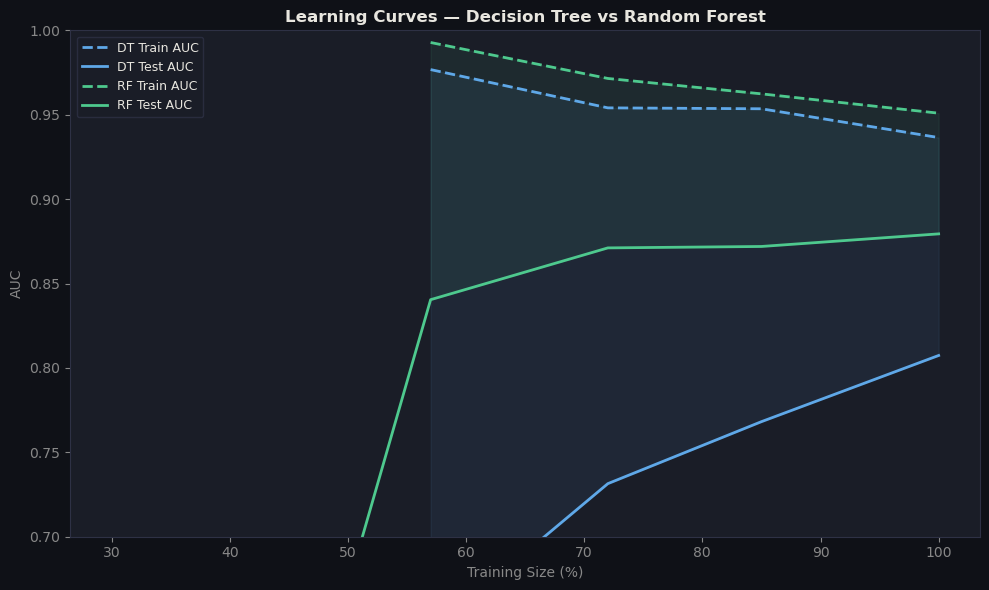

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f1117')

DARK   = '#0f1117'
CARD   = '#1a1d27'
DT_COL = '#5fa8e8'
RF_COL = '#4ec98e'
TEXT   = '#e8e6df'
MUTED  = '#888888'

ax.set_facecolor(CARD)
sizes_pct = [int(s * 100) for s in train_sizes]

ax.plot(sizes_pct, dt_train_aucs, color=DT_COL, lw=2, linestyle='--', label='DT Train AUC')
ax.plot(sizes_pct, dt_val_aucs,   color=DT_COL, lw=2, label='DT Test AUC')
ax.plot(sizes_pct, rf_train_aucs, color=RF_COL, lw=2, linestyle='--', label='RF Train AUC')
ax.plot(sizes_pct, rf_val_aucs,   color=RF_COL, lw=2, label='RF Test AUC')
ax.fill_between(sizes_pct, dt_train_aucs, dt_val_aucs, alpha=0.08, color=DT_COL)
ax.fill_between(sizes_pct, rf_train_aucs, rf_val_aucs, alpha=0.08, color=RF_COL)

ax.set_xlabel('Training Size (%)', color=MUTED)
ax.set_ylabel('AUC', color=MUTED)
ax.set_ylim(0.7, 1.0)
ax.tick_params(colors=MUTED)
ax.legend(fontsize=9, facecolor=CARD, labelcolor=TEXT, edgecolor='#2e3145')
ax.set_title('Learning Curves — Decision Tree vs Random Forest', 
             fontsize=12, fontweight='bold', color=TEXT)
for spine in ax.spines.values():
    spine.set_edgecolor('#2e3145')

plt.tight_layout()
plt.savefig('../figures/learning_curves_combined.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()

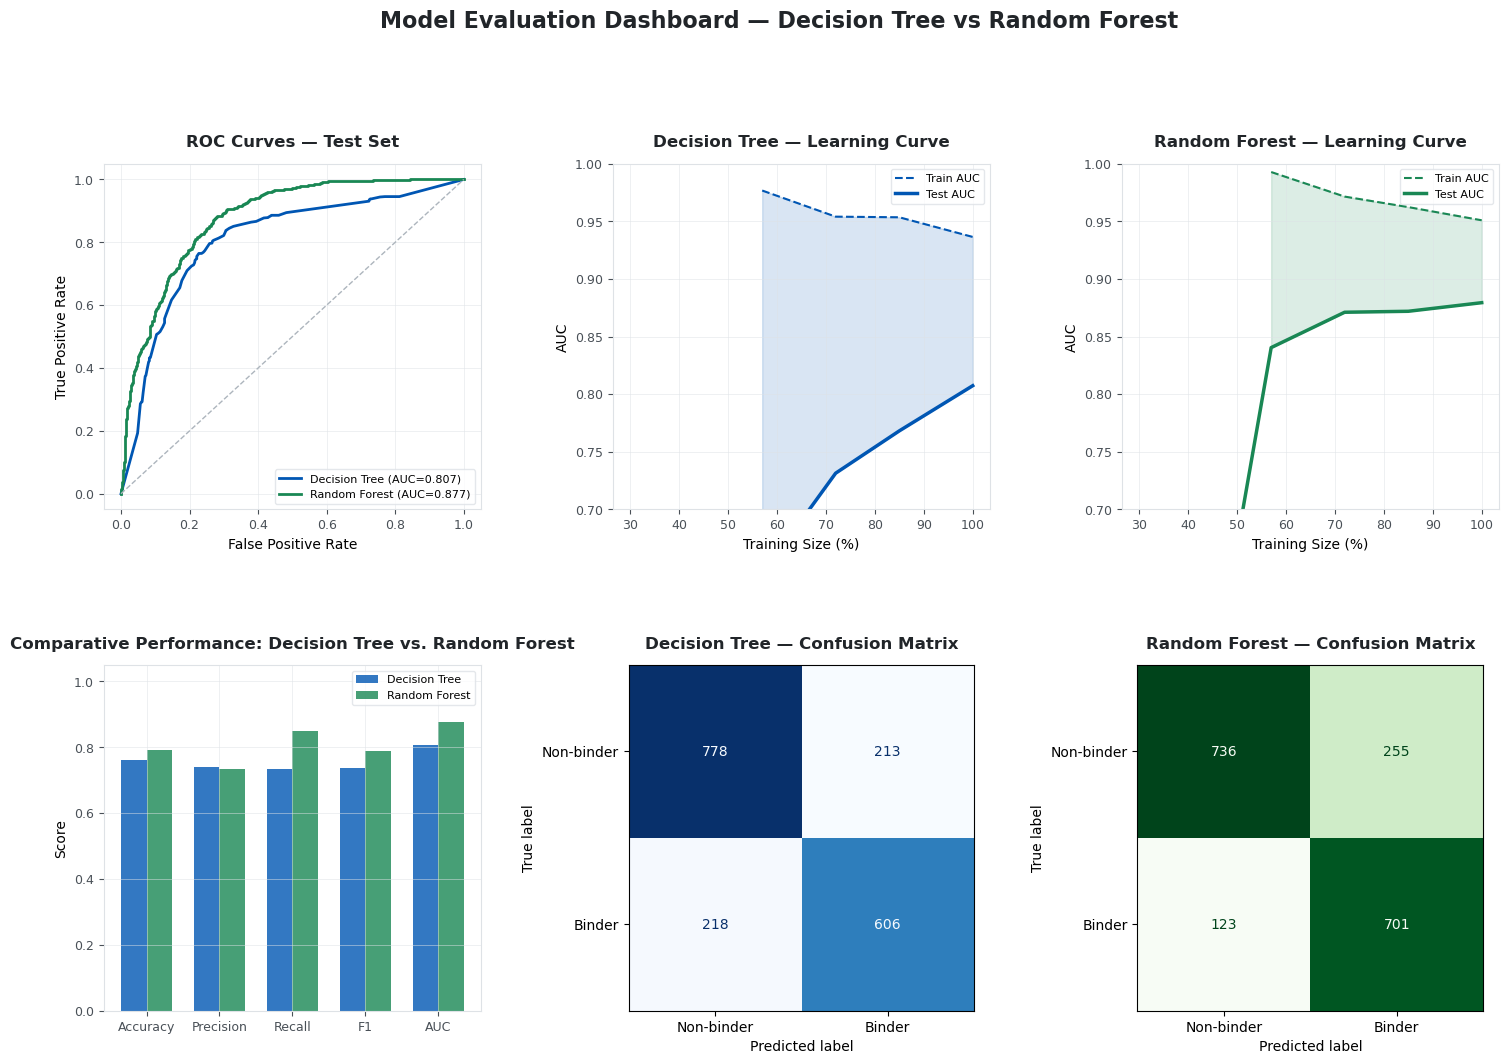

Plot saved to ../figures/combined_model_evaluation.png


In [ ]:
# 5. PLOT EVERYTHING
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#FFFFFF')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Color Palette: Standardized theme
BG_WHITE = '#FFFFFF'
TEXT     = '#212529' 
MUTED    = '#495057'
GRID     = '#DEE2E6'
DT_COL   = '#0056b3' # Strong Blue
RF_COL   = '#198754' # Deep Green

def style_ax(ax, title):
    # Set plot area to white and apply grid styling
    ax.set_facecolor(BG_WHITE)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', color=TEXT, pad=12)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(True, linestyle='-', color=GRID, linewidth=0.5, alpha=0.7)

# Panel 1: ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(dt_fpr, dt_tpr, color=DT_COL, lw=2, label=f'Decision Tree (AUC={dt_auc:.3f})')
ax1.plot(rf_fpr, rf_tpr, color=RF_COL, lw=2, label=f'Random Forest (AUC={rf_auc:.3f})')
ax1.plot([0,1], [0,1], color='#ADB5BD', lw=1, linestyle='--')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=8, facecolor=BG_WHITE, edgecolor=GRID)
style_ax(ax1, 'ROC Curves — Test Set')

# Panel 2: DT Learning Curve
ax2 = fig.add_subplot(gs[0, 1])
sizes_pct = [int(s * 100) for s in train_sizes]
ax2.plot(sizes_pct, dt_train_aucs, color=DT_COL, lw=1.5, linestyle='--', label='Train AUC')
ax2.plot(sizes_pct, dt_val_aucs,   color=DT_COL, lw=2.5, label='Test AUC')
ax2.fill_between(sizes_pct, dt_train_aucs, dt_val_aucs, alpha=0.15, color=DT_COL)
ax2.set_xlabel('Training Size (%)'); ax2.set_ylabel('AUC')
ax2.set_ylim(0.7, 1.0)
ax2.legend(fontsize=8, facecolor=BG_WHITE, edgecolor=GRID)
style_ax(ax2, 'Decision Tree — Learning Curve')

# Panel 3: RF Learning Curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(sizes_pct, rf_train_aucs, color=RF_COL, lw=1.5, linestyle='--', label='Train AUC')
ax3.plot(sizes_pct, rf_val_aucs,   color=RF_COL, lw=2.5, label='Test AUC')
ax3.fill_between(sizes_pct, rf_train_aucs, rf_val_aucs, alpha=0.15, color=RF_COL)
ax3.set_xlabel('Training Size (%)'); ax3.set_ylabel('AUC')
ax3.set_ylim(0.7, 1.0)
ax3.legend(fontsize=8, facecolor=BG_WHITE, edgecolor=GRID)
style_ax(ax3, 'Random Forest — Learning Curve')

# Panel 4: Metrics Comparison
ax4 = fig.add_subplot(gs[1, 0])
x = np.arange(len(metrics_names))
w = 0.35
ax4.bar(x - w/2, dt_scores, w, color=DT_COL, alpha=0.8, label='Decision Tree')
ax4.bar(x + w/2, rf_scores, w, color=RF_COL, alpha=0.8, label='Random Forest')
ax4.set_xticks(x); ax4.set_xticklabels(metrics_names, fontsize=9)
ax4.set_ylim(0, 1.05); ax4.set_ylabel('Score')
ax4.legend(fontsize=8, facecolor=BG_WHITE, edgecolor=GRID)
style_ax(ax4, 'Comparative Performance: Decision Tree vs. Random Forest')

# Panel 5: DT Confusion Matrix
ax5 = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(dt_cm, display_labels=['Non-binder','Binder']).plot(ax=ax5, colorbar=False, cmap='Blues')
ax5.set_title('Decision Tree — Confusion Matrix', fontsize=12, fontweight='bold', color=TEXT, pad=12)
ax5.grid(False) 

# Panel 6: RF Confusion Matrix
ax6 = fig.add_subplot(gs[1, 2])
ConfusionMatrixDisplay(rf_cm, display_labels=['Non-binder','Binder']).plot(ax=ax6, colorbar=False, cmap='Greens')
ax6.set_title('Random Forest — Confusion Matrix', fontsize=12, fontweight='bold', color=TEXT, pad=12)
ax6.grid(False) 

plt.suptitle('Model Evaluation Dashboard — Decision Tree vs Random Forest', fontsize=16, fontweight='bold', color=TEXT, y=1.02)
plt.savefig('../figures/combined_model_evaluation.png', dpi=300, bbox_inches='tight', facecolor=BG_WHITE)
plt.show()
print("Plot saved to ../figures/combined_model_evaluation.png")

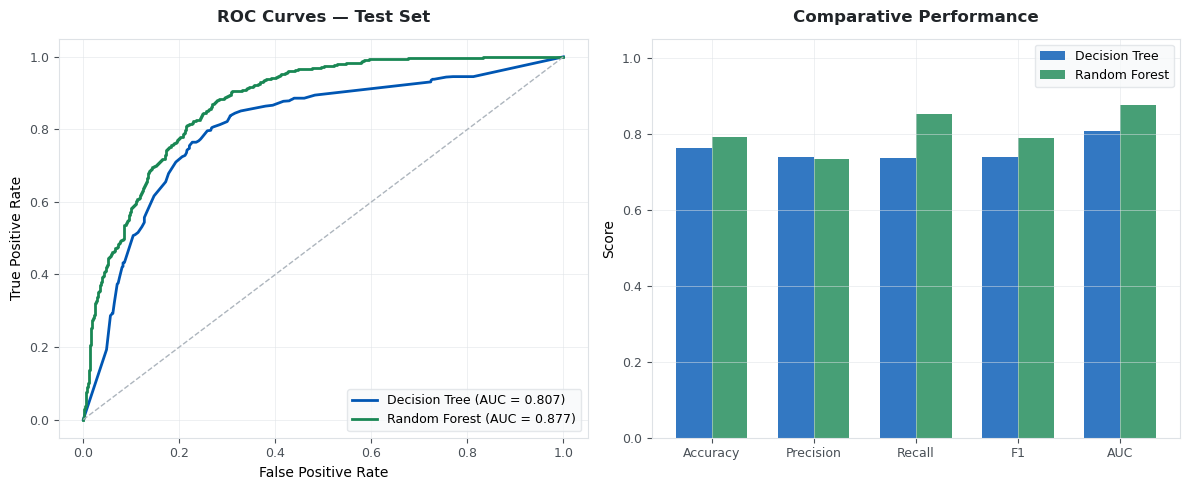

In [34]:
# Create a new figure with only 1 row and 2 columns
fig_small, (ax1, ax4) = plt.subplots(1, 2, figsize=(12, 5))
fig_small.patch.set_facecolor('#FFFFFF')

# Panel 1: ROC Curves
ax1.plot(dt_fpr, dt_tpr, color=DT_COL, lw=2, label=f'Decision Tree (AUC = {dt_auc:.3f})')
ax1.plot(rf_fpr, rf_tpr, color=RF_COL, lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
ax1.plot([0,1],[0,1], color='#ADB5BD', lw=1, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=9, facecolor=AX_GRAY, edgecolor=GRID)
style_ax(ax1, 'ROC Curves — Test Set')

# Panel 4: Metrics Comparison
x = np.arange(len(metrics_names))
w = 0.35
ax4.bar(x - w/2, dt_scores, w, color=DT_COL, alpha=0.8, label='Decision Tree')
ax4.bar(x + w/2, rf_scores, w, color=RF_COL, alpha=0.8, label='Random Forest')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names, fontsize=9)
ax4.set_ylim(0, 1.05)
ax4.set_ylabel('Score')
ax4.legend(fontsize=9, facecolor=AX_GRAY, edgecolor=GRID)
style_ax(ax4, 'Comparative Performance')

plt.tight_layout()
plt.savefig('../figures/roc_and_metrics_panel.png', dpi=300, bbox_inches='tight')
plt.show()